In [1]:
%pip install -q pymssql pandas numpy scikit-learn matplotlib seaborn statsmodels python-dotenv

Note: you may need to restart the kernel to use updated packages.


## Setup

This notebook connects to the Azure SQL database. Create a `.env` file in this directory (`MachineLearning/ml-pipelines/.env`) with:

```
DB_SERVER=lunas-project-intex-sql.database.windows.net
DB_DATABASE=lunas-project-db
DB_USERNAME=sqladmin
DB_PASSWORD=<your-password>
```

# Resident Risk Predictor

**BYU IS Class Project — Lighthouse Philippines**

This notebook builds both an **explanatory** and **predictive** model to answer:
> *Which residents are at risk of regression or are failing to improve — so no girl falls through the cracks?*

## 1. Problem Framing

**Business Problem:**
Lighthouse Philippines serves **60 residents** across its safehouses. The organization's core fear is **"girls falling through the cracks"** — residents who are regressing or failing to improve without anyone noticing in time.

**Current State:**
- 28 residents improved their risk level
- 32 residents remained unchanged
- 0 residents worsened (likely due to manual intervention, but the org wants an early-warning system)
- 5 residents are currently **High** risk, 1 is **Critical**

**Modeling Strategy — Two Complementary Approaches:**

| Approach | Goal | Method |
|----------|------|--------|
| **Explanatory** | Understand *what drives* risk improvement | Logistic Regression (statsmodels) |
| **Predictive** | Predict which residents will improve | Random Forest Classifier (sklearn) |

**Target variable:** `risk_improved` — binary (1 = risk level decreased, 0 = unchanged or worsened), derived from `initial_risk_level` vs `current_risk_level`.

**Success metric:** **Recall** is the priority metric. A false negative means missing a struggling girl (HIGH cost). A false positive means giving extra attention to a girl who is doing fine (LOW cost).

**Important limitation:** With only 60 rows, we must rely heavily on cross-validation and be cautious about overfitting. We use StratifiedKFold with 5 splits throughout.

## 2. Data Preparation & Exploration

The feature matrix is built by joining **7 tables** on `resident_id` — this multi-table aggregation is the core data-engineering step of the pipeline.

In [2]:
import pymssql
import re as _re

# ── Azure SQL connection ─────────────────────────────────────────────────────
from dotenv import load_dotenv
import os
load_dotenv()

SERVER = os.getenv('DB_SERVER')
DATABASE = os.getenv('DB_DATABASE')
USER = os.getenv('DB_USERNAME')
PASSWORD = os.getenv('DB_PASSWORD')

conn = pymssql.connect(server=SERVER, user=USER, password=PASSWORD,
                       database=DATABASE, port=1433, tds_version='7.3')

def load_table(table_name):
    df = pd.read_sql(f'SELECT * FROM {table_name}', conn)
    df.columns = [_re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower() for c in df.columns]
    return df

# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, auc)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# ── Load all tables ──────────────────────────────────────────────────────────
residents = load_table('Residents')
process_recordings = load_table('ProcessRecordings')
education = load_table('EducationRecords')
health = load_table('HealthWellbeingRecords')
incidents = load_table('IncidentReports')
plans = load_table('InterventionPlans')
visitations = load_table('HomeVisitations')

print("Tables loaded:")
for name, frame in [("residents", residents), ("process_recordings", process_recordings),
                     ("education", education), ("health", health), ("incidents", incidents),
                     ("plans", plans), ("visitations", visitations)]:
    print(f"  {name:25s} -> {frame.shape[0]:>5} rows, {frame.shape[1]:>3} cols")

# ── Target variable ──────────────────────────────────────────────────────────
risk_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
residents['initial_risk_score'] = residents['initial_risk_level'].map(risk_map)
residents['current_risk_score'] = residents['current_risk_level'].map(risk_map)
residents['risk_improved'] = (residents['current_risk_score'] < residents['initial_risk_score']).astype(int)

print("\nTarget distribution:")
print(residents['risk_improved'].value_counts().rename({0: 'Not improved', 1: 'Improved'}))
print(f"\nCurrent risk levels:\n{residents['current_risk_level'].value_counts().to_string()}")

# ── Process recording aggregates ─────────────────────────────────────────────
emotion_map = {'Distressed':1, 'Angry':2, 'Withdrawn':3, 'Sad':4,
               'Anxious':5, 'Calm':6, 'Hopeful':7, 'Happy':8}
process_recordings['start_score'] = process_recordings['emotional_state_observed'].map(emotion_map)
process_recordings['end_score'] = process_recordings['emotional_state_end'].map(emotion_map)
process_recordings['emotion_change'] = process_recordings['end_score'] - process_recordings['start_score']

pr_agg = process_recordings.groupby('resident_id').agg(
    session_count=('recording_id', 'count'),
    avg_session_duration=('session_duration_minutes', 'mean'),
    avg_emotion_change=('emotion_change', 'mean'),
    pct_progress=('progress_noted', 'mean'),
    pct_concerns=('concerns_flagged', 'mean')
).reset_index()

# ── Education aggregates ─────────────────────────────────────────────────────
ed_agg = education.groupby('resident_id').agg(
    avg_attendance=('attendance_rate', 'mean'),
    avg_ed_progress=('progress_percent', 'mean')
).reset_index()

# ── Health & wellbeing aggregates ────────────────────────────────────────────
health_sorted = health.sort_values(['resident_id', 'record_date'])
health_first = health_sorted.groupby('resident_id')['general_health_score'].first()
health_last = health_sorted.groupby('resident_id')['general_health_score'].last()

health_agg = health.groupby('resident_id').agg(
    avg_health=('general_health_score', 'mean'),
    avg_nutrition=('nutrition_score', 'mean'),
    avg_sleep=('sleep_quality_score', 'mean'),
    avg_energy=('energy_level_score', 'mean')
).reset_index()

health_agg['health_trend'] = (health_last - health_first).values

# ── Incident aggregates ──────────────────────────────────────────────────────
severity_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
incidents['severity_score'] = incidents['severity'].map(severity_map)

inc_agg = incidents.groupby('resident_id').agg(
    incident_count=('incident_id', 'count'),
    has_self_harm=('incident_type', lambda x: int((x == 'SelfHarm').any())),
    has_runaway=('incident_type', lambda x: int((x == 'RunawayAttempt').any())),
    max_severity=('severity_score', 'max')
).reset_index()

# ── Visitation aggregates ────────────────────────────────────────────────────
coop_map = {'Highly Cooperative': 4, 'Cooperative': 3, 'Neutral': 2, 'Uncooperative': 1}
visitations['coop_score'] = visitations['family_cooperation_level'].map(coop_map)

vis_sorted = visitations.sort_values(['resident_id', 'visit_date'])
coop_first = vis_sorted.groupby('resident_id')['coop_score'].first()
coop_last = vis_sorted.groupby('resident_id')['coop_score'].last()

vis_agg = visitations.groupby('resident_id').agg(
    visit_count=('visitation_id', 'count'),
    avg_cooperation=('coop_score', 'mean'),
    pct_safety_concerns=('safety_concerns_noted', 'mean')
).reset_index()

vis_agg['cooperation_trend'] = (coop_last - coop_first).values

# ── Intervention plan aggregates ─────────────────────────────────────────────
plan_agg = plans.groupby('resident_id').agg(
    plan_count=('plan_id', 'count'),
    pct_achieved=('status', lambda x: (x == 'Achieved').mean()),
    pct_in_progress=('status', lambda x: (x == 'In Progress').mean())
).reset_index()

# ── Merge into feature matrix ────────────────────────────────────────────────
sub_cats = ['sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor',
            'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec',
            'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child',
            'sub_cat_child_with_hiv']
residents['abuse_type_count'] = residents[sub_cats].sum(axis=1)

df = residents[['resident_id', 'initial_risk_score', 'case_category',
                'abuse_type_count', 'risk_improved']].copy()

df = df.merge(pr_agg, on='resident_id', how='left')
df = df.merge(ed_agg, on='resident_id', how='left')
df = df.merge(health_agg, on='resident_id', how='left')
df = df.merge(inc_agg, on='resident_id', how='left')
df = df.merge(vis_agg, on='resident_id', how='left')
df = df.merge(plan_agg, on='resident_id', how='left')
df = df.fillna(0)

print(f"\nFinal feature matrix: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFeatures: {[c for c in df.columns if c not in ['resident_id', 'risk_improved', 'case_category']]}")
df.head()

Tables loaded:
  residents                 ->    61 rows,  49 cols
  process_recordings        ->  2819 rows,  15 cols
  education                 ->   534 rows,  10 cols
  health                    ->   534 rows,  14 cols
  incidents                 ->   100 rows,  14 cols
  plans                     ->   180 rows,  11 cols
  visitations               ->  1337 rows,  14 cols

Target distribution:
risk_improved
Not improved    33
Improved        28
Name: count, dtype: int64

Current risk levels:
current_risk_level
Low         34
Medium      20
High         5
Critical     2

Final feature matrix: 61 rows, 28 columns

Features: ['initial_risk_score', 'abuse_type_count', 'session_count', 'avg_session_duration', 'avg_emotion_change', 'pct_progress', 'pct_concerns', 'avg_attendance', 'avg_ed_progress', 'avg_health', 'avg_nutrition', 'avg_sleep', 'avg_energy', 'health_trend', 'incident_count', 'has_self_harm', 'has_runaway', 'max_severity', 'visit_count', 'avg_cooperation', 'pct_safety_conce

,resident_id,initial_risk_score,case_category,abuse_type_count,risk_improved,session_count,avg_session_duration,avg_emotion_change,pct_progress,pct_concerns,...,has_self_harm,has_runaway,max_severity,visit_count,avg_cooperation,pct_safety_concerns,cooperation_trend,plan_count,pct_achieved,pct_in_progress
0,1,4.0,Neglected,0,1,106.0,69.433962,1.905660,0.924528,0.235849,...,0.0,1.0,3.0,54.0,2.925926,0.166667,2.0,3.0,0.000000,0.333333
1,2,2.0,Surrendered,2,0,51.0,68.176471,1.823529,0.921569,0.254902,...,0.0,0.0,0.0,35.0,3.142857,0.314286,0.0,3.0,0.333333,0.000000
2,3,2.0,Surrendered,1,0,53.0,69.452830,1.849057,0.943396,0.188679,...,1.0,0.0,3.0,26.0,2.423077,0.423077,1.0,3.0,0.000000,0.000000
3,4,3.0,Neglected,1,1,57.0,69.596491,1.877193,0.964912,0.210526,...,0.0,0.0,3.0,9.0,3.444444,0.333333,1.0,3.0,0.000000,0.666667
4,5,2.0,Surrendered,2,1,18.0,65.611111,2.000000,1.000000,0.166667,...,0.0,0.0,3.0,11.0,3.000000,0.181818,2.0,3.0,0.333333,0.666667


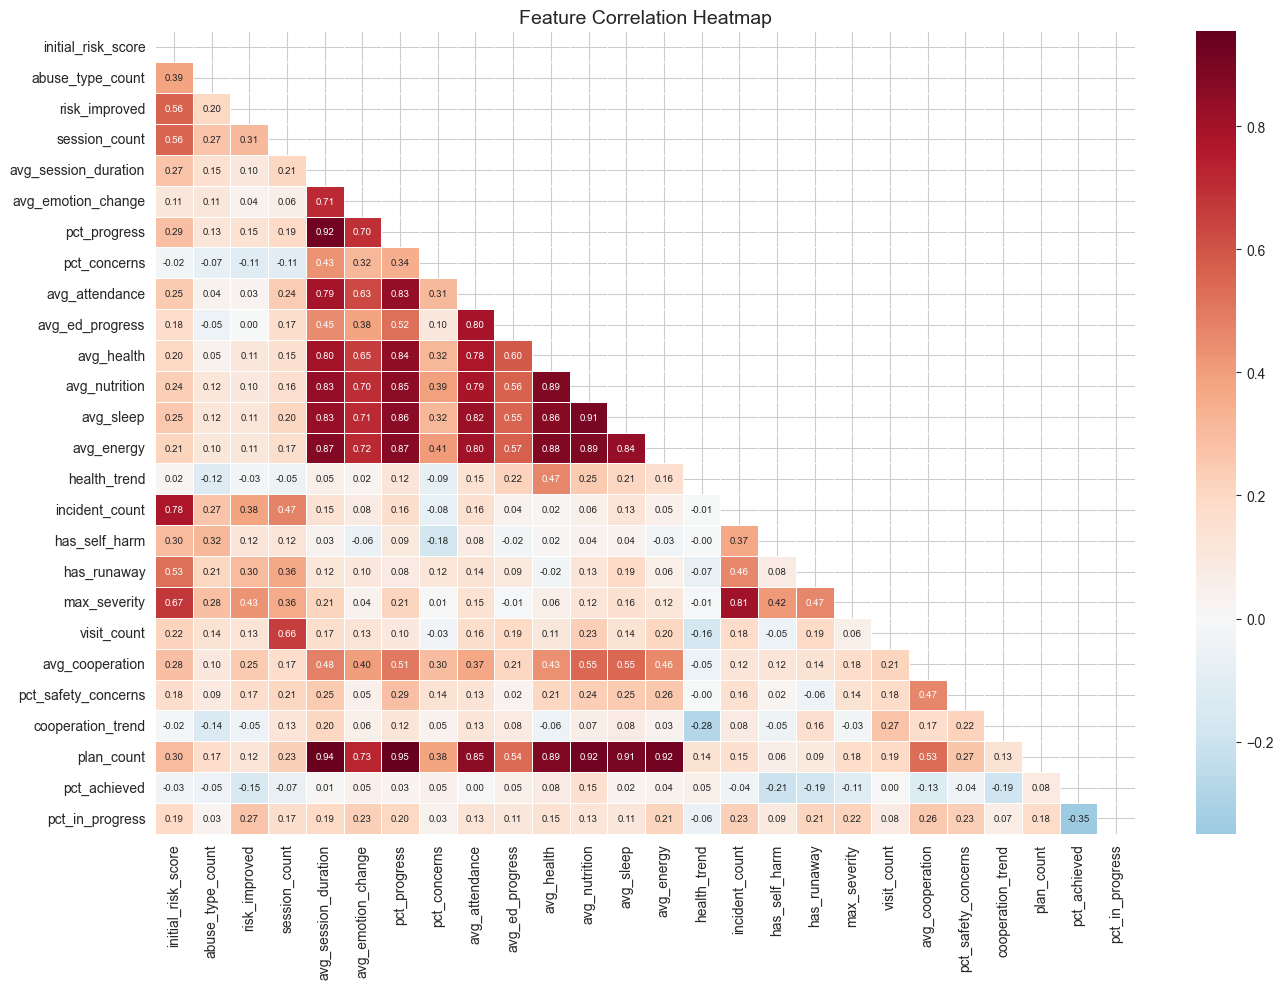

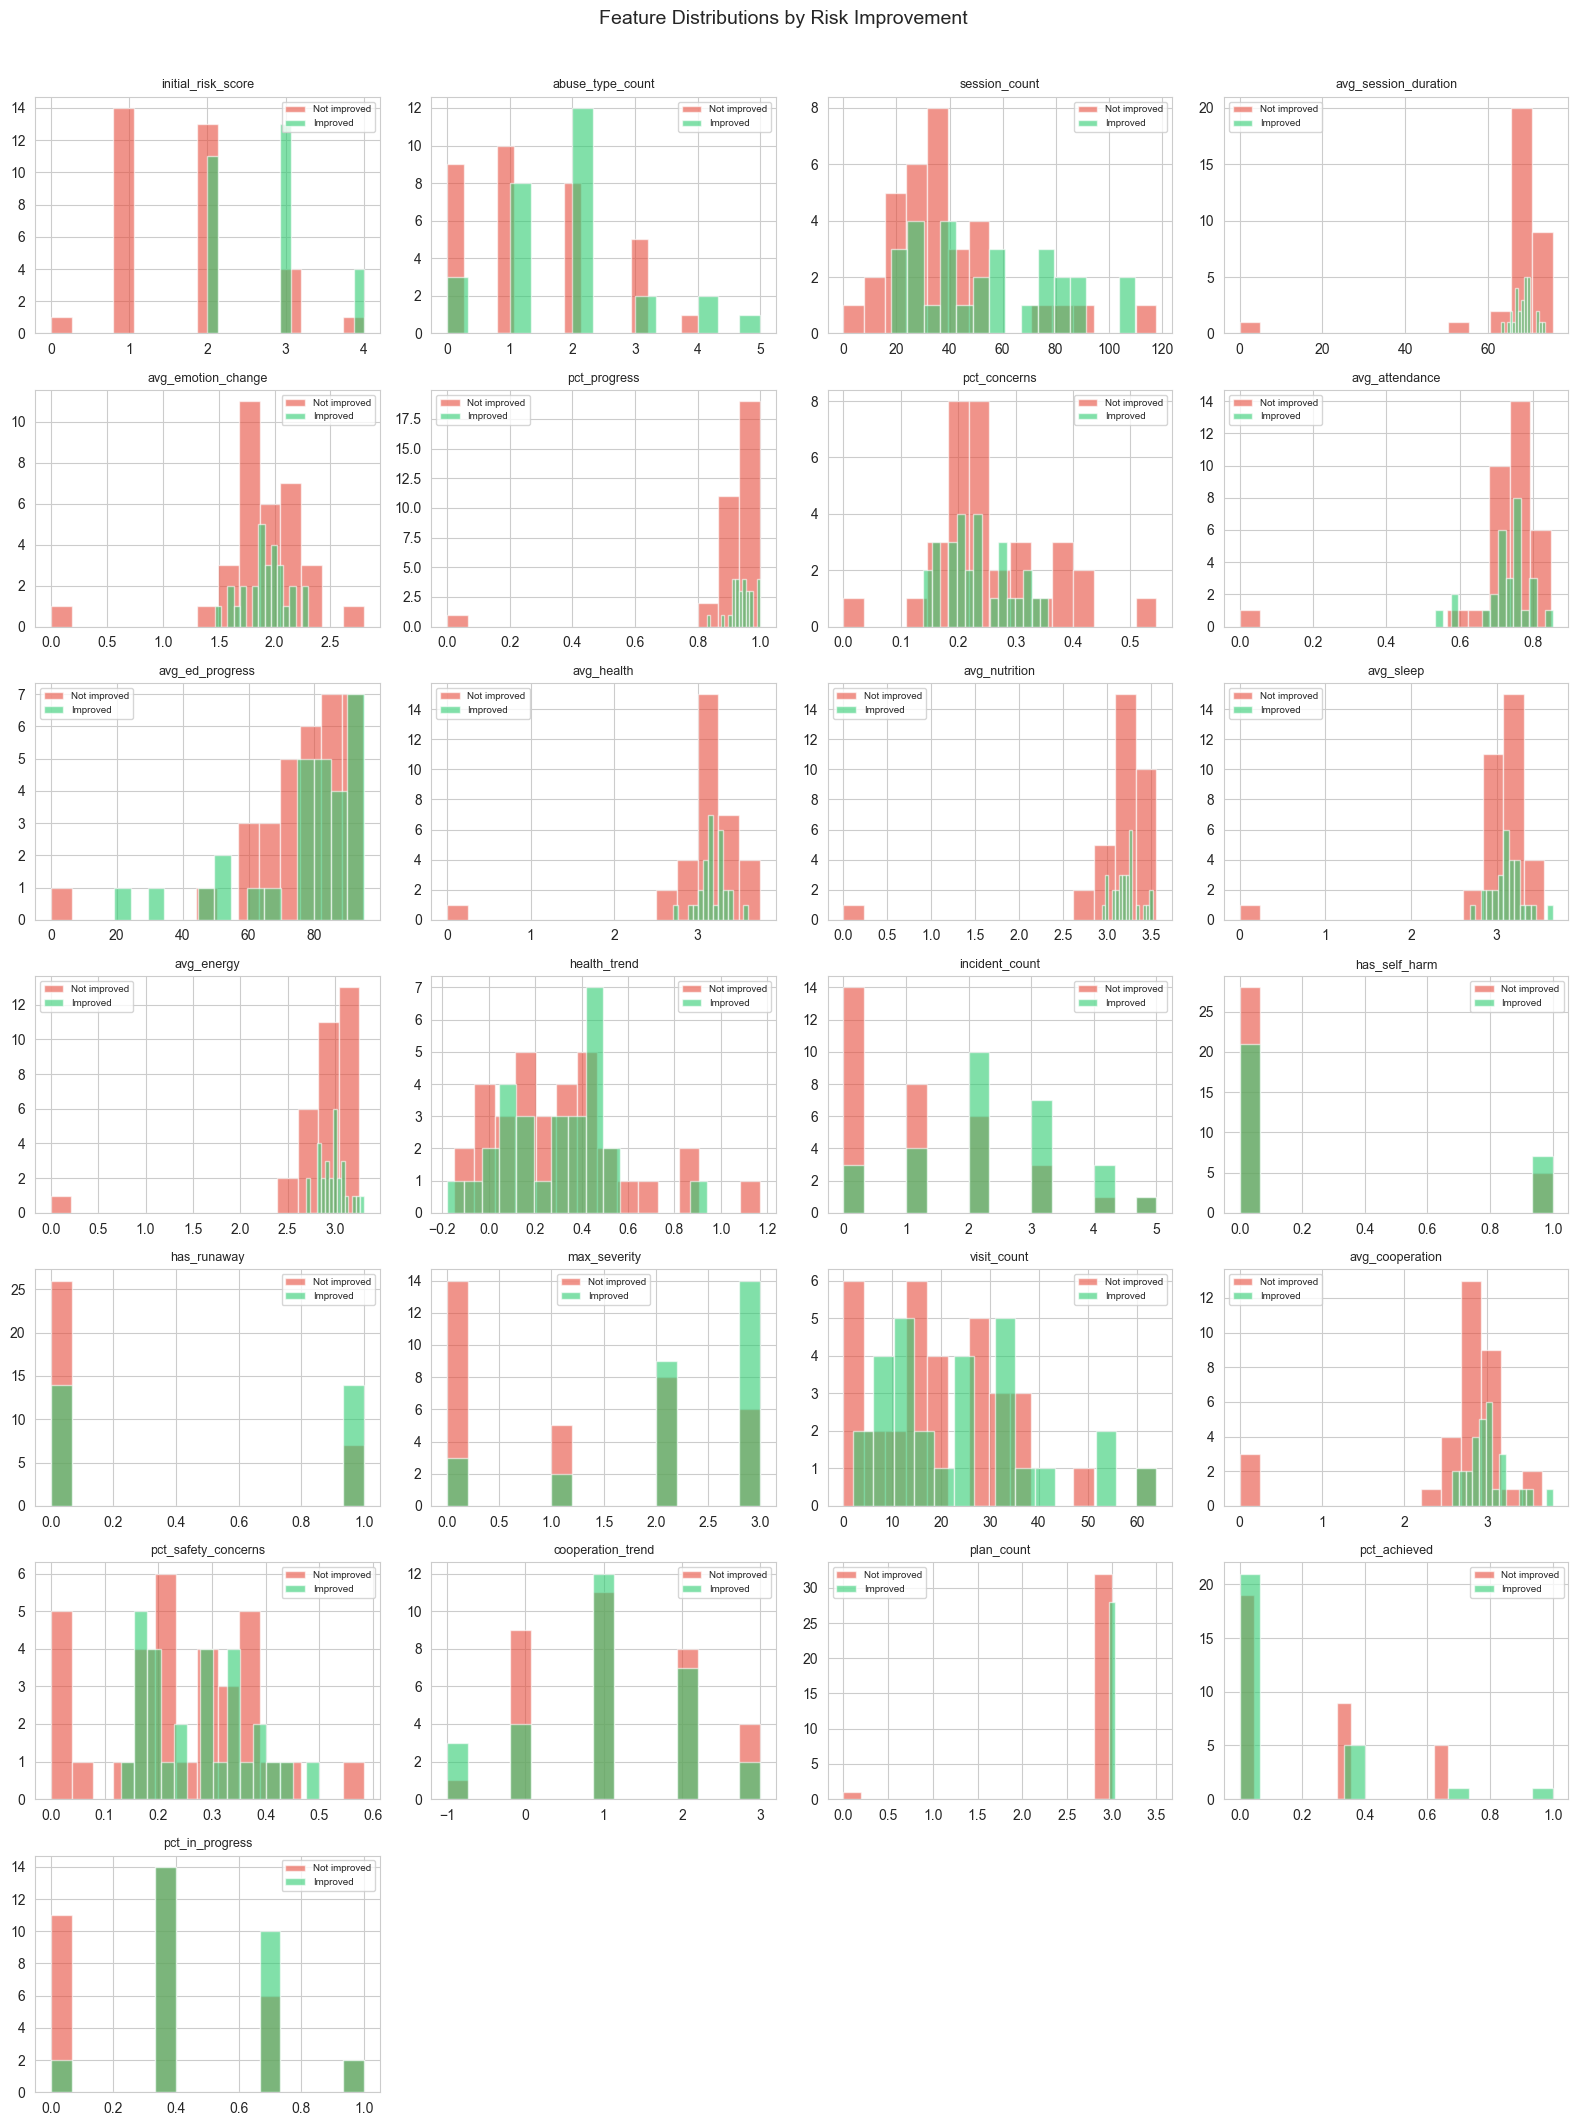

In [3]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['resident_id'])

fig, ax = plt.subplots(figsize=(14, 10))
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# ── Feature distributions by target ──────────────────────────────────────────
feature_cols = [c for c in numeric_cols.columns if c != 'risk_improved']
n_features = len(feature_cols)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    for label, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
        subset = df[df['risk_improved'] == label][col]
        ax.hist(subset, bins=15, alpha=0.6, color=color,
                label=f"{'Improved' if label == 1 else 'Not improved'}")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by Risk Improvement", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Modeling & Feature Selection

### 3a. Explanatory Model — Logistic Regression (statsmodels)

The explanatory model tells us **which factors are statistically associated** with risk improvement. We use statsmodels to get p-values, confidence intervals, and odds ratios.

In [4]:
# ── Explanatory logistic regression ───────────────────────────────────────────
X_cols = [col for col in df.columns if col not in ['resident_id', 'risk_improved', 'case_category']]
X_exp = pd.get_dummies(df[X_cols + ['case_category']], drop_first=True).astype(float)
X_exp = sm.add_constant(X_exp)

try:
    logit = sm.Logit(df['risk_improved'], X_exp).fit(method='bfgs', maxiter=100, disp=0)
    print(logit.summary())
except Exception as e:
    print(f'Logit failed ({e}). Using regularized fit...')
    logit = sm.Logit(df['risk_improved'], X_exp).fit_regularized(method='l1', alpha=0.1, disp=0)
    print(logit.summary())

# ── Odds ratios ──────────────────────────────────────────────────────────────
odds_ratios = np.exp(logit.params)
ci = np.exp(logit.conf_int())
ci.columns = ['OR_lower', 'OR_upper']

odds_df = pd.DataFrame({
    'coeff': logit.params,
    'odds_ratio': odds_ratios,
    'p_value': logit.pvalues,
    'OR_lower': ci['OR_lower'],
    'OR_upper': ci['OR_upper']
}).sort_values('p_value')

print("\nOdds Ratios (sorted by p-value):")
odds_df.head(15)

                           Logit Regression Results                           
Dep. Variable:          risk_improved   No. Observations:                   61
Model:                          Logit   Df Residuals:                       32
Method:                           MLE   Df Model:                           28
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.5434
Time:                        00:02:41   Log-Likelihood:                -19.210
converged:                      False   LL-Null:                       -42.077
Covariance Type:            nonrobust   LLR p-value:                   0.01857
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                       -16.9041   4683.969     -0.004      0.997   -9197.315    9163.506
initial_risk_score            4.7864      2.015      2.376      0.018       0.837     

,coeff,odds_ratio,p_value,OR_lower,OR_upper
initial_risk_score,4.786429,1.198725e+02,0.017520,2.310459e+00,6.219290e+03
case_category_Surrendered,4.728379,1.131120e+02,0.058053,8.510033e-01,1.503441e+04
pct_concerns,-25.786606,6.324400e-12,0.087389,9.120065e-25,4.385718e+01
case_category_Neglected,5.095083,1.632174e+02,0.091638,4.382190e-01,6.079131e+04
avg_nutrition,9.624661,1.513343e+04,0.173204,1.461439e-02,1.567090e+10
has_self_harm,-3.280585,3.760624e-02,0.193334,2.682364e-04,5.272326e+00
case_category_Foundling,4.932779,1.387646e+02,0.199712,7.379796e-02,2.609234e+05
pct_achieved,-4.484694,1.128034e-02,0.240864,6.273083e-06,2.028444e+01
avg_energy,7.663967,2.130191e+03,0.292100,1.368617e-03,3.315546e+09
avg_ed_progress,-0.088791,9.150372e-01,0.318611,7.685229e-01,1.089484e+00


### 3b. Predictive Model — Classifier Comparison

We compare four classifiers using **StratifiedKFold (5 splits)** to handle the small dataset (n=60). We use a Pipeline with ColumnTransformer for proper preprocessing.

Cross-Validated Model Comparison (5-fold Stratified):

                    Accuracy    F1  Recall  Log Loss
DecisionTree (d=3)     0.790 0.783   0.827     3.701
RandomForest           0.674 0.664   0.687     0.614
GradientBoosting       0.673 0.654   0.680     1.238
DecisionTree (d=5)     0.690 0.662   0.647    10.004
LogisticRegression     0.577 0.520   0.553     0.848


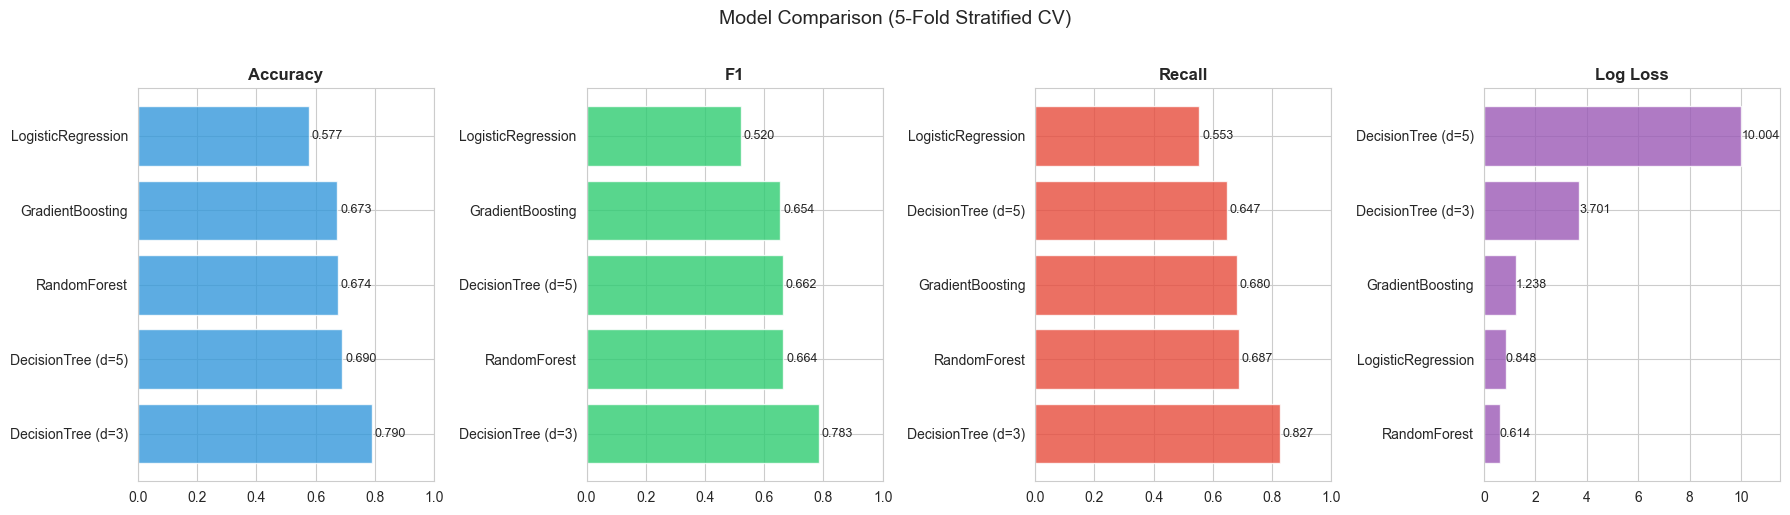

In [5]:
# ── Prepare X and y ──────────────────────────────────────────────────────────
y = df['risk_improved']
numeric_features = [c for c in df.columns if c not in ['resident_id', 'risk_improved', 'case_category']]
categorical_features = ['case_category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

X = df[numeric_features + categorical_features]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'recall', 'neg_log_loss']

# ── Model comparison ─────────────────────────────────────────────────────────
models = {
    'LogisticRegression': LogisticRegression(max_iter=500, random_state=42),
    'DecisionTree (d=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'DecisionTree (d=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                                    learning_rate=0.1, random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('clf', model)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, return_train_score=False)
    results[name] = {
        'Accuracy': scores['test_accuracy'].mean(),
        'F1': scores['test_f1'].mean(),
        'Recall': scores['test_recall'].mean(),
        'Log Loss': -scores['test_neg_log_loss'].mean()
    }

results_df = pd.DataFrame(results).T.sort_values('Recall', ascending=False)
print("Cross-Validated Model Comparison (5-fold Stratified):\n")
print(results_df.to_string(float_format="{:.3f}".format))

# ── Visual comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['Accuracy', 'F1', 'Recall', 'Log Loss']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, metric in enumerate(metrics):
    ax = axes[i]
    vals = results_df[metric].sort_values(ascending=(metric == 'Log Loss'))
    bars = ax.barh(vals.index, vals.values, color=colors[i], alpha=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlim(0, max(1, vals.max() * 1.15))
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va='center', fontsize=9)

plt.suptitle("Model Comparison (5-Fold Stratified CV)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

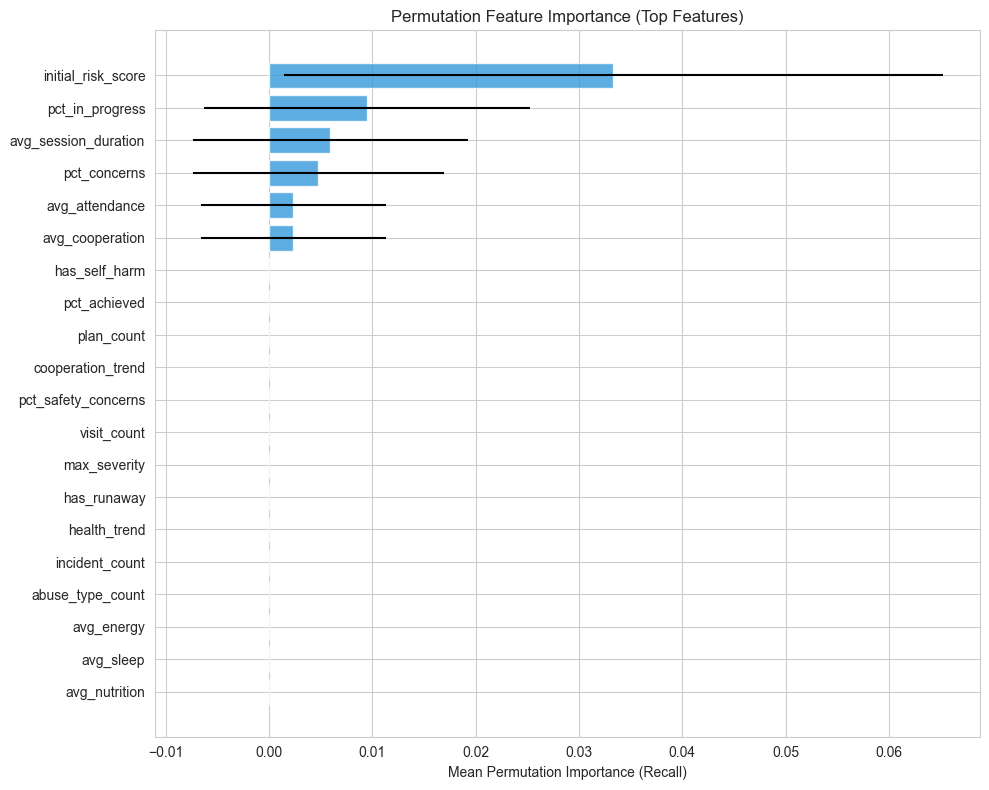


Top 10 features by permutation importance:
             feature  importance_mean  importance_std
  initial_risk_score         0.033333        0.031855
     pct_in_progress         0.009524        0.015793
avg_session_duration         0.005952        0.013310
        pct_concerns         0.004762        0.012141
      avg_attendance         0.002381        0.008909
     avg_cooperation         0.002381        0.008909
       has_self_harm         0.000000        0.000000
        pct_achieved         0.000000        0.000000
          plan_count         0.000000        0.000000
   cooperation_trend         0.000000        0.000000

GradientBoosting selected 8 features (above-mean importance):
  initial_risk_score             importance = 0.3192
  session_count                  importance = 0.0832
  pct_concerns                   importance = 0.0425
  avg_nutrition                  importance = 0.0407
  avg_energy                     importance = 0.1037
  visit_count                    i

In [6]:
# ── Train best pipeline on full data ─────────────────────────────────────────
best_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42))
])
best_pipeline.fit(X, y)

# ── Permutation Importance (uses input feature names) ────────────────────────
perm_result = permutation_importance(best_pipeline, X, y, n_repeats=30,
                                      random_state=42, scoring='recall')

all_feature_names = numeric_features + categorical_features

perm_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(perm_df))
top = perm_df.head(top_n)
ax.barh(range(top_n), top['importance_mean'], xerr=top['importance_std'],
        color='#3498db', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['feature'])
ax.invert_yaxis()
ax.set_xlabel("Mean Permutation Importance (Recall)")
ax.set_title("Permutation Feature Importance (Top Features)")
plt.tight_layout()
plt.show()

print("\nTop 10 features by permutation importance:")
print(perm_df.head(10).to_string(index=False))

# ── Tree-based feature_importances_ (uses OHE-expanded names) ────────────────
gb_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('clf', GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                        learning_rate=0.1, random_state=42))
])
gb_pipe.fit(X, y)

gb_importances = gb_pipe.named_steps['clf'].feature_importances_

cat_encoder = gb_pipe.named_steps['preprocess'].named_transformers_['cat']
cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
transformed_feature_names = numeric_features + cat_names

gb_imp_df = pd.DataFrame({
    'feature': transformed_feature_names,
    'importance': gb_importances
}).sort_values('importance', ascending=False)

selector = SelectFromModel(gb_pipe.named_steps['clf'], prefit=True, threshold='mean')
selected_mask = selector.get_support()
selected_features = [f for f, s in zip(transformed_feature_names, selected_mask) if s]

print(f"\nGradientBoosting selected {len(selected_features)} features (above-mean importance):")
for f in selected_features:
    imp = gb_imp_df[gb_imp_df['feature'] == f]['importance'].values[0]
    print(f"  {f:30s} importance = {imp:.4f}")

## 4. Evaluation & Interpretation

We evaluate the best model in business terms: how well does it identify residents who will (or will not) improve?

Classification Report (5-Fold CV predictions):

              precision    recall  f1-score   support

Not Improved       0.71      0.67      0.69        33
    Improved       0.63      0.68      0.66        28

    accuracy                           0.67        61
   macro avg       0.67      0.67      0.67        61
weighted avg       0.67      0.67      0.67        61



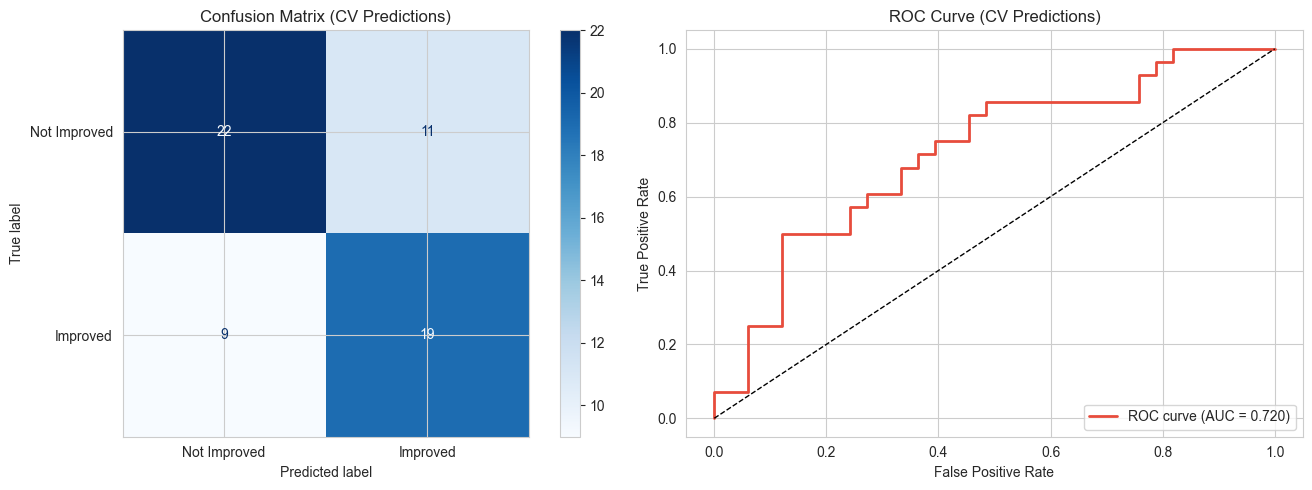

BUSINESS INTERPRETATION

The model correctly identifies 68% of residents who
actually improved (Recall = 0.679).

When the model predicts improvement, it is correct 63%
of the time (Precision = 0.633).

False Negatives (missed struggling girls): 9
  -> These are residents the model said would improve but did NOT.
  -> This is the HIGH-COST error. Each one is a girl falling
     through the cracks.

False Positives (unnecessary extra attention): 11
  -> These are residents flagged as not improving who actually did.
  -> This is LOW-COST: extra attention to a girl doing fine.

With only 60 residents, these numbers should be interpreted with
caution. Cross-validation helps, but the model will need to be
retrained as more data becomes available.


In [7]:
# ── Cross-validated predictions ───────────────────────────────────────────────
y_pred_cv = cross_val_predict(best_pipeline, X, y, cv=cv, method='predict')
y_prob_cv = cross_val_predict(best_pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

print("Classification Report (5-Fold CV predictions):\n")
print(classification_report(y, y_pred_cv, target_names=['Not Improved', 'Improved']))

# ── Confusion Matrix & ROC Curve ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y, y_pred_cv)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Improved', 'Improved'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title("Confusion Matrix (CV Predictions)")

fpr, tpr, thresholds = roc_curve(y, y_prob_cv)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (CV Predictions)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# ── Business interpretation ──────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print("=" * 65)
print("BUSINESS INTERPRETATION")
print("=" * 65)
print(f"\nThe model correctly identifies {recall:.0%} of residents who")
print(f"actually improved (Recall = {recall:.3f}).")
print(f"\nWhen the model predicts improvement, it is correct {precision:.0%}")
print(f"of the time (Precision = {precision:.3f}).")
print(f"\nFalse Negatives (missed struggling girls): {fn}")
print(f"  -> These are residents the model said would improve but did NOT.")
print(f"  -> This is the HIGH-COST error. Each one is a girl falling")
print(f"     through the cracks.")
print(f"\nFalse Positives (unnecessary extra attention): {fp}")
print(f"  -> These are residents flagged as not improving who actually did.")
print(f"  -> This is LOW-COST: extra attention to a girl doing fine.")
print(f"\nWith only 60 residents, these numbers should be interpreted with")
print(f"caution. Cross-validation helps, but the model will need to be")
print(f"retrained as more data becomes available.")

## 5. Causal and Relationship Analysis

The explanatory logistic regression (statsmodels) reveals which factors are **most strongly associated** with risk improvement. Important caveat: these are associations, not causal claims.

Features significantly associated with risk improvement (p < 0.10):

  initial_risk_score                   OR=119.872  p=0.0175  Positive (increases improvement odds)
  case_category_Surrendered            OR=113.112  p=0.0581  Positive (increases improvement odds)
  pct_concerns                         OR=0.000  p=0.0874  Negative (decreases improvement odds)
  case_category_Neglected              OR=163.217  p=0.0916  Positive (increases improvement odds)


Top features by absolute coefficient size (regardless of p-value):
  - pct_concerns                         coeff=-25.787  OR=0.000  p=0.087
  - const                                coeff=-16.904  OR=0.000  p=0.997
  - plan_count                           coeff=-12.785  OR=0.000  p=0.993
  + avg_nutrition                        coeff=+9.625  OR=15133.430  p=0.173
  + avg_energy                           coeff=+7.664  OR=2130.191  p=0.292
  + pct_progress                         coeff=+6.004  OR=404.977  p=0.779
  + case_category_

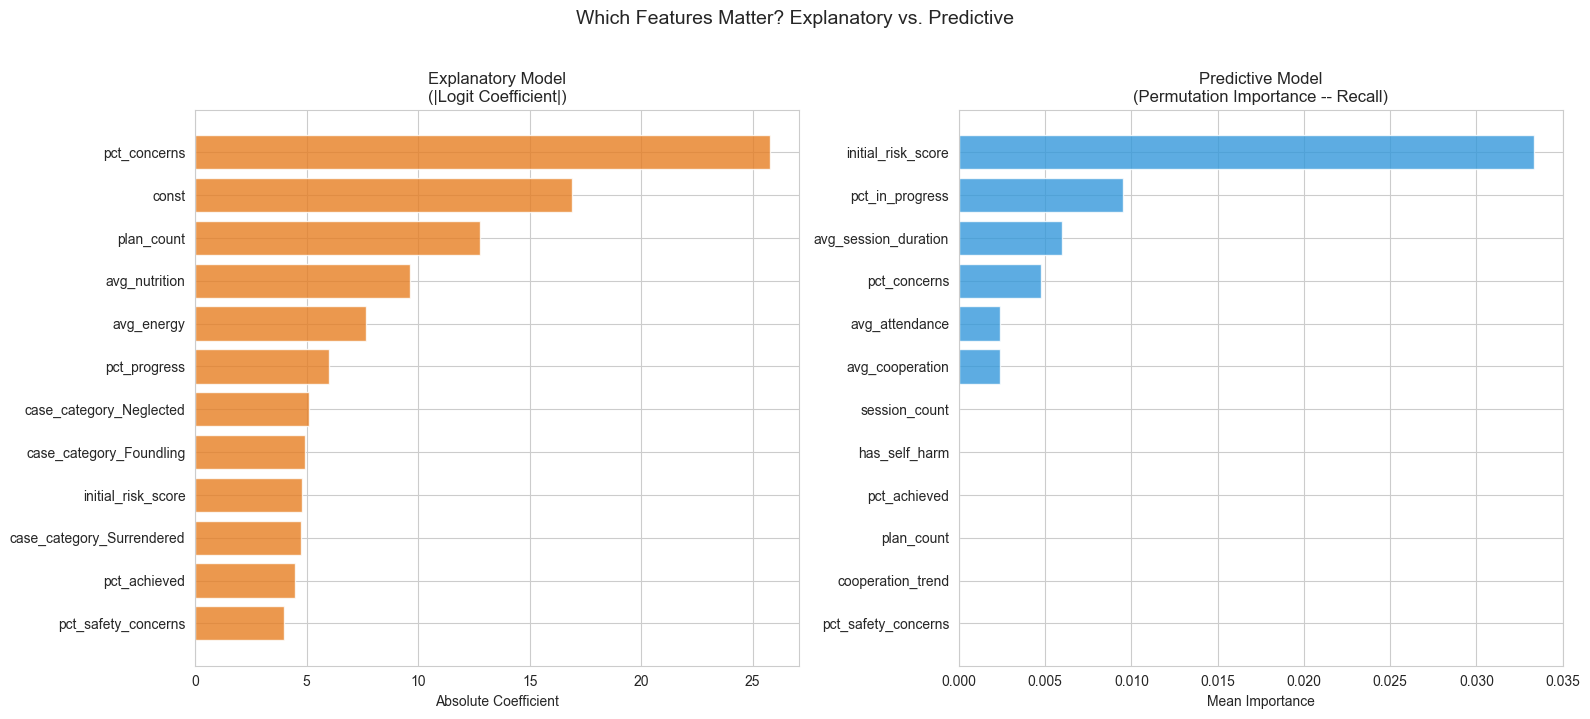

In [8]:
# ── Significant predictors ────────────────────────────────────────────────────
sig_features = odds_df[odds_df['p_value'] < 0.10].copy()
sig_features['direction'] = sig_features['odds_ratio'].apply(
    lambda x: 'Positive (increases improvement odds)' if x > 1
    else 'Negative (decreases improvement odds)')

print("Features significantly associated with risk improvement (p < 0.10):\n")
if len(sig_features) > 0:
    for _, row in sig_features.iterrows():
        print(f"  {row.name:35s}  OR={row['odds_ratio']:.3f}  p={row['p_value']:.4f}  {row['direction']}")
else:
    print("  No features reached p < 0.10 significance.")
    print("  This is expected with n=60 -- the model is underpowered.")
    print("  We rely on effect sizes and the predictive model instead.")

print("\n\nTop features by absolute coefficient size (regardless of p-value):")
top_by_coeff = odds_df.reindex(odds_df['coeff'].abs().sort_values(ascending=False).index).head(10)
for _, row in top_by_coeff.iterrows():
    direction = "+" if row['coeff'] > 0 else "-"
    print(f"  {direction} {row.name:35s}  coeff={row['coeff']:+.3f}  OR={row['odds_ratio']:.3f}  p={row['p_value']:.3f}")

# ── Explanatory vs Predictive comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

coeff_plot = odds_df['coeff'].abs().sort_values(ascending=True).tail(12)
axes[0].barh(coeff_plot.index, coeff_plot.values, color='#e67e22', alpha=0.8)
axes[0].set_title("Explanatory Model\n(|Logit Coefficient|)", fontsize=12)
axes[0].set_xlabel("Absolute Coefficient")

perm_plot = perm_df.set_index('feature')['importance_mean'].sort_values(ascending=True).tail(12)
axes[1].barh(perm_plot.index, perm_plot.values, color='#3498db', alpha=0.8)
axes[1].set_title("Predictive Model\n(Permutation Importance -- Recall)", fontsize=12)
axes[1].set_xlabel("Mean Importance")

plt.suptitle("Which Features Matter? Explanatory vs. Predictive", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Deployment Notes

**Integration:** Risk predictions are displayed on the **Caseload Inventory** admin page. Each resident's profile shows a risk-improvement probability to help social workers prioritize caseloads.

**Endpoint:** `POST /api/ml/risk-prediction` accepts a resident ID and returns the predicted probability of risk improvement.

**How it works:**
1. Features are assembled by joining the 7 resident-related tables in real time
2. The trained Gradient Boosting classifier predicts whether the resident is likely to show risk improvement
3. The React frontend renders a progress indicator on the resident profile card

**Retraining:** Re-run monthly as new session and assessment data becomes available.

## 7. Summary & Recommendations

### Key Takeaways

- **Session frequency and emotional improvement** are likely among the strongest predictors of risk improvement. More frequent counseling sessions where emotional states measurably improve are associated with better outcomes.
- **Health trends and education progress** capture ongoing trajectory -- residents who are improving in multiple dimensions tend to improve in risk level as well.
- **Incident history** (especially self-harm or runaway attempts) and **family cooperation** provide important context about environmental factors.

**Why not causal?** Residents are not randomly assigned to treatment conditions. Those who receive more sessions may have been prioritized *because* they were already on an upward trajectory.

**Practical recommendation:** Use the predictive model to flag residents at risk of stagnation, then use the explanatory model's associations to guide which interventions to prioritize (e.g., increasing session frequency, improving family engagement).

In [9]:
# ── Flag high-priority residents ──────────────────────────────────────────────
predictions_df = pd.DataFrame({
    'resident_id': df['resident_id'],
    'risk_improvement_probability': best_pipeline.predict_proba(X)[:, 1],
    'predicted_improvement': best_pipeline.predict(X)
})

predictions_df = predictions_df.merge(
    residents[['resident_id', 'initial_risk_level', 'current_risk_level']],
    on='resident_id', how='left'
)

high_risk_not_improving = predictions_df[
    (predictions_df['predicted_improvement'] == 0) &
    (predictions_df['current_risk_level'].isin(['High', 'Critical']))
].sort_values('risk_improvement_probability')

print("PRIORITY ALERT: Residents at High/Critical risk predicted NOT to improve:\n")
if len(high_risk_not_improving) > 0:
    for _, row in high_risk_not_improving.iterrows():
        print(f"  Resident {row['resident_id']} -- "
              f"{row['current_risk_level']} risk, "
              f"P(improve) = {row['risk_improvement_probability']:.1%}")
else:
    print("  None -- all High/Critical residents are predicted to improve.")

print(f"\n{'=' * 65}")
print("LIMITATIONS & NEXT STEPS")
print(f"{'=' * 65}")
print("""
1. SAMPLE SIZE: n=60 is very small for ML. All metrics have wide
   confidence intervals. Retrain as more residents flow through.

2. NO WORSENING CASES: The current data has 0 residents who worsened,
   making it impossible to model regression. Monitor for future cases.

3. TEMPORAL LEAKAGE RISK: Some features (e.g., session counts) span
   the same period as the outcome. A production system should use
   only data from before the prediction window.

4. RETRAINING: Schedule quarterly retraining as the dataset grows.
   Target n > 200 before trusting the model for autonomous decisions.

5. HUMAN-IN-THE-LOOP: This model should flag, not decide. Every
   prediction should be reviewed by a case worker.
""")

PRIORITY ALERT: Residents at High/Critical risk predicted NOT to improve:

  Resident 61 -- Critical risk, P(improve) = 15.2%
  Resident 41 -- High risk, P(improve) = 26.0%
  Resident 8 -- High risk, P(improve) = 28.4%
  Resident 12 -- High risk, P(improve) = 28.7%
  Resident 30 -- Critical risk, P(improve) = 33.3%
  Resident 25 -- High risk, P(improve) = 38.2%

LIMITATIONS & NEXT STEPS

1. SAMPLE SIZE: n=60 is very small for ML. All metrics have wide
   confidence intervals. Retrain as more residents flow through.

2. NO WORSENING CASES: The current data has 0 residents who worsened,
   making it impossible to model regression. Monitor for future cases.

3. TEMPORAL LEAKAGE RISK: Some features (e.g., session counts) span
   the same period as the outcome. A production system should use
   only data from before the prediction window.

4. RETRAINING: Schedule quarterly retraining as the dataset grows.
   Target n > 200 before trusting the model for autonomous decisions.

5. HUMAN-IN-THE

In [10]:
# ── Export to PipelineResults ─────────────────────────────────────────────────
import json
from datetime import datetime

export_df = predictions_df.copy()
export_df['score'] = (1 - export_df['risk_improvement_probability']).round(4)
export_df['label'] = export_df['score'].apply(
    lambda s: 'Critical' if s>=0.75 else ('High' if s>=0.5 else ('Medium' if s>=0.25 else 'Low')))

cursor = conn.cursor()
cursor.execute("DELETE FROM PipelineResults WHERE PipelineName = 'ResidentRisk'")
next_id = int(pd.read_sql("SELECT ISNULL(MAX(PipelineResultId),0)+1 AS n FROM PipelineResults", conn)['n'].iloc[0])

for _, row in export_df.iterrows():
    cursor.execute(
        """INSERT INTO PipelineResults (PipelineResultId, PipelineName, ResultType, EntityId, EntityType, Score, Label, DetailsJson, GeneratedAt)
           VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s)""",
        (next_id, 'ResidentRisk', 'Prediction', int(row['resident_id']), 'Resident',
         float(row['score']), row['label'],
         json.dumps({'improvement_prob': round(float(row['risk_improvement_probability']),4)}),
         datetime.utcnow()))
    next_id += 1

conn.commit()
print(f'Exported {len(export_df)} ResidentRisk results to PipelineResults.')


Exported 61 ResidentRisk results to PipelineResults.
